# 17_机器学习模型评估方法-AUC

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/creditcard.csv`。

转写调整：

- 信用卡数据默认固定分层抽样 30000 行并保持原类别比例；load_creditcard(sample_size=None) 可读全量数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文咱们一起来聊聊：AUC\~

AUC 是「Area Under Curve」的缩写，中文意思是「曲线下面积」。在机器学习里，AUC 通常指的是 ROC 曲线下面积，也就是「AUC-ROC」。

通俗点说：我们用模型来判断某个东西是不是“正例”（比如判断一封邮件是不是垃圾邮件），模型会给出一个“分数”或者“概率”。然后我们根据这个分数来决定它到底是“正例”还是“负例”。

但是分数不是结果，我们要设一个“阈值”（比如说 0.5）来做判断，大于 0.5 就认为是正例，小于 0.5 就认为是负例。问题是，阈值不同，判断结果也会变。这时候我们就用 AUC 来评估模型在所有“可能阈值”下的整体表现。

**简单理解：AUC 表示模型区分正负样本的能力，数值越接近 1 越好。**

#### 一个小例子：

假设你有两个样本：

- 样本A是正例（1），模型打分 0.9；
- 样本B是负例（0），模型打分 0.2。

这时，模型判断对了，AUC 就等于 1（100% 正确区分）。

如果反过来：

- A 得 0.2，B 得 0.9，那模型就完全错了，AUC 就是 0。

如果 A 得 0.6，B 得 0.6，打了一样的分数，那模型就没法区分，AUC 是 0.5。

### AUC 数学原理

AUC 是 ROC 曲线下面积，那 ROC 曲线是什么？

ROC 曲线是在不同阈值下，**真阳性率（True Positive Rate, TPR）** 和 **假阳性率（False Positive Rate, FPR）** 的关系图。

- 横轴：FPR = 假阳性 / 所有负例 = FP / (FP + TN)
- 纵轴：TPR = 真阳性 / 所有正例 = TP / (TP + FN)

当我们从高到低遍历所有阈值，计算每个阈值下的 TPR 和 FPR，画出来就是 ROC 曲线。

AUC 就是这条 ROC 曲线下面的面积。

### AUC 的公式推理和计算原理

#### 1. 理解从积分角度的定义（曲线下面积）

AUC 是一条曲线下面积，它可以用积分公式表示为：


$$
\text{AUC} = \int_{0}^{1} TPR(FPR^{-1}(x)) \, dx
$$


这个数学公式表达的是：把 ROC 曲线在 [0,1] 区间下的面积积分计算出来。

但在实际中，我们一般不这么复杂地算，而是用离散点近似计算曲线下的面积（常用梯形法则）。

#### 2. 从概率角度理解 AUC

AUC 也可以理解为这样一个概率：

> **随机抽一个正样本和一个负样本，模型打分让正样本得分更高的概率**

用公式写就是：


$$
\text{AUC} = P(\text{score}(X_{\text{正}}) > \text{score}(X_{\text{负}}))
$$


也就是说，AUC 越接近 1，说明模型越能正确区分正负样本。

#### 3. AUC 的常用计算方法（基于排序）

假设你有：

$N_{\text{正}}$ 个正样本；

$N_{\text{负}}$ 个负样本。

我们按照模型给出的得分，对所有样本进行排序，记录所有正样本在排序中的排名 $R_i$。

则：


$$
\text{AUC} = \frac{ \sum_{i=1}^{N_{\text{正}}} (R_i - i) }{N_{\text{正}} \cdot N_{\text{负}}}
$$


这个公式的含义：

- 每个正样本的排序名次减去它在正样本里的名次，得到它在负样本中“超过”的个数；
- 所有正样本的“超越”个数总和，除以总的正负样本对数，得到 AUC。

### AUC 计算的流程

**步骤1：准备数据**

- 数据集中每个样本有一个真实标签（0 或 1）；
- 每个样本有一个模型打分（通常是概率）；

**步骤2：将样本按打分从高到低排序**

- 这一步是为了构造 ROC 曲线；
- 同样用于排序计算 AUC；

步骤3：遍历所有可能的阈值，计算 TPR 和 FPR

- 对每一个分数作为“阈值”，进行正负分类；
- 计算出 TP、FP、TN、FN；
- 计算 TPR = TP / (TP + FN)；
- 计算 FPR = FP / (FP + TN)；

#### 步骤4：画出 ROC 曲线

- 以 FPR 为横轴，TPR 为纵轴，画出所有点；
- 将这些点连起来；

#### 步骤5：计算 ROC 曲线下的面积

- 通过数值积分（比如梯形法）；
- 或通过排序公式快速计算；

下面，咱们通过一个完整的案例来进行理解\~

## 完整案例

我们使用一个公开数据集来预测**信用卡交易是否为欺诈**。这是一个非常典型的**类别极度不平衡**问题，非常适合使用 AUC 作为模型评估指标。

数据集在公众号：深夜努力写Python，后台回复「数据集」既可获取\~

数据集包含：

- 284,807 条交易记录
- 每条记录有 30 个变量（特征 V1\~V28，Time，Amount）
- 标签列为 `Class`：1 表示欺诈，0 表示正常

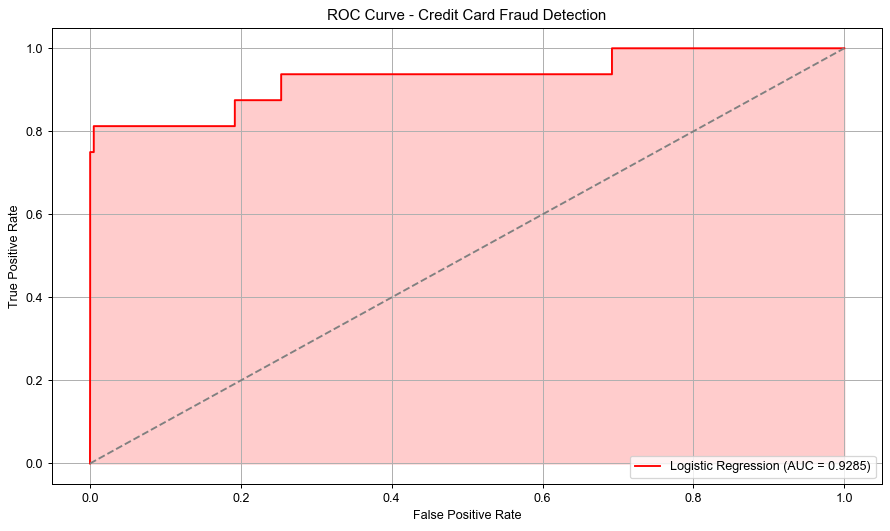

Confusion Matrix:
 [[8910   74]
 [   3   13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      8984
           1       0.15      0.81      0.25        16

    accuracy                           0.99      9000
   macro avg       0.57      0.90      0.62      9000
weighted avg       1.00      0.99      0.99      9000

AUC Score: 0.9285


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report


# 1. 加载数据
df = load_creditcard()

# 2. 特征缩放
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 3. 分离特征和标签
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

# 4. 划分训练集和测试集（注意保持比例）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

# 5. 使用逻辑回归进行训练
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

# 6. 模型预测：输出概率
y_scores = model.predict_proba(X_test)[:, 1]

# 7. 计算 ROC 曲线与 AUC 分数
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

# 8. 绘制 ROC 曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='red', label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.fill_between(fpr, tpr, alpha=0.2, color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Card Fraud Detection')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 9. 打印混淆矩阵和分类报告
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)
print(f"AUC Score: {auc_score:.4f}")

#### Step 1：加载数据

我们从 CSV 文件中加载信用卡交易数据，每一行是一次交易记录。

In [3]:
df = load_creditcard()

#### Step 2：特征缩放

特征“Amount”数值范围差异较大，使用 `StandardScaler` 标准化处理（均值0、方差1），使模型训练更稳定。

In [4]:
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

#### Step 3：准备特征和标签

- 去掉无用特征 `Time`（按时间排序并无帮助）
- `Class` 是我们要预测的目标（1为欺诈）

In [5]:
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

#### Step 4：数据划分

- 我们使用 `train_test_split` 将数据集按 7:3 划分；
- `stratify=y` 表示保持原始类别分布，防止正负样本比例失衡。

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

#### Step 5：训练模型（逻辑回归）

- 逻辑回归是一种经典的二分类算法；
- 我们使用 `class_weight="balanced"` 自动对少数类样本加权处理，提升效果。

In [7]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Step 6：模型打分

- 不仅预测类别，还输出每个样本为“正例”的概率（用来画 ROC）

In [8]:
y_scores = model.predict_proba(X_test)[:, 1]

#### Step 7：计算 ROC 曲线和 AUC 值

- ROC 曲线衡量模型在不同阈值下的表现；
- AUC 是这条曲线下面积，用于综合评价模型性能。

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

#### Step 8：绘制 ROC 曲线

![原文参考图，当前结果见代码输出](attachments/img_011.png)

- 红色线条表示模型性能；
- 灰色虚线表示随机分类的水平。

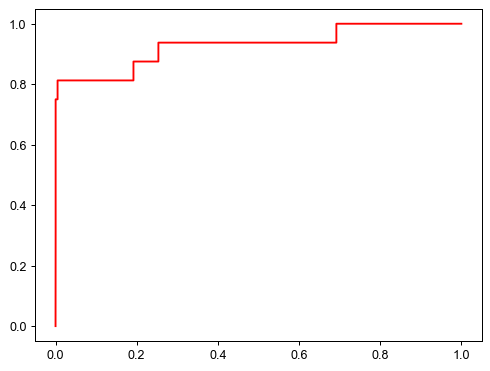

In [10]:
plt.plot(fpr, tpr, color='red')

#### Step 9：打印性能评估

虽然 AUC 衡量的是“排序能力”，我们也补充了**准确率、召回率、F1 值、混淆矩阵**来进一步验证模型表现。

### AUC 优缺点分析

**优点：**

1. **对类别不平衡鲁棒性强：**  
不受正负样本比例影响，适用于大部分现实场景。
2. **评价的是排序能力而不是分类能力：**  
AUC 衡量的是模型输出的概率是否合理，而不是在特定阈值下是否准确。
3. **无需指定阈值：**  
比如你不知道使用 0.5 作为判断标准是否合理时，AUC 提供了一个全局评价视角。
4. **图形可视化好：**  
ROC 曲线易于解释和展示，在业务报告中很常用。

**缺点：**

1. **不能反映特定业务代价：**  
比如医疗场景中错判一个病人比漏判 10 个正常人严重，AUC 无法体现这种「代价差异」。
2. **不能用于模型部署阈值选择：**  
AUC 虽然评估排序好坏，但部署模型时仍需选一个合适的阈值。
3. **不适用于高类不平衡但对 recall 有极高要求的场景：**  
比如刑侦、金融反欺诈场景，更关注召回率（Recall）而不是排序整体性能。

### AUC 适用场景

- **信用评分、欺诈识别、广告点击预测、医疗诊断等**：当你关心的是「模型能否把正例排在负例前面」时，AUC 是最佳选择。
- **类别分布极不平衡时**：如 99.9% 是负类，准确率无意义，此时 AUC 非常关键。
- **模型对输出概率可靠性要求高的任务**：比如推荐系统、电商订单转化率建模等。

在这个案例中，我们使用信用卡欺诈检测作为背景任务，用逻辑回归训练模型，使用 `AUC-ROC` 方法全面评估模型在正负样本区分上的能力；

AUC 是机器学习中最常用也最强大的评估指标之一，尤其在数据不平衡的现实世界问题中，它的重要性不可替代。